<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Tabrajo de Fin de Master</header1></center>
<left><h1>Desarollo de Herramienta Visual para el Análisis de datos de Accidentes Viales</header1></left>

Presentado por: <br>
Didier Waldemar Heredia Barragan <br>
Fecha: 10/01/2024

## Importación de librerias necesarias

In [1]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd
from pandas import read_csv
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


## Cargar el Dataset

In [2]:
#Código para cargar el Dataset
# Se define la direccion de donde se encuentra el archivo, como se encuentra en la misma carpeta se coloca solo el nombre
url = 'BDD_ENE_2017_OCT_2023_1.csv'
# Se ejecuta el comando de pandas que nos permite leer el archivo csv
dataset = pd.read_csv('BDD_ENE_2017_OCT_2023_1.csv',encoding = "ANSI")
# imprimos el valor ola forma de nuestro dataset
print(dataset.shape)

(156412, 56)


In [3]:
dataset = pd.read_csv('BDD_ENE_2017_OCT_2023_1.csv',encoding = "ANSI")

In [4]:
print(dataset.shape)

(156412, 56)


In [5]:
# Imprimimos las 5 primeras filas para verficiar que los datos se cargaron
dataset.head()

,ID,ANIO,SINIESTROS,LESIONADOS,FALLECIDOS,ENTE_DE_CONTROL,LATITUD_Y,LONGITUD_X,DPA_1,PROVINCIA,...,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,TIPO_ID_1,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1
0,1,2017,DMQ00001012017,1,0,AGENCIA METROPOLITANA DE TRANSITO DE QUITO - AMT,-0.083501,-78.417742,17,PICHINCHA,...,0,0,1,CEDULA,36,MUJER,LESIONADO,PEATON,NO,NO
1,2,2017,ATM00002012017,1,0,AGENCIA DE TRANSITO Y MOVILIDAD DE GUAYAQUIL -...,-2.246682,-79.897754,9,GUAYAS,...,0,0,1,CEDULA,12,HOMBRE,LESIONADO,PEATON,NO,NO
2,3,2017,PNE00003012017,1,0,POLICIA NACIONAL DEL ECUADOR,-0.253881,-79.217405,23,SANTO DOMINGO DE LOS TSACHILAS,...,0,0,1,CEDULA,26,HOMBRE,LESIONADO,PEATON,NO,NO
3,4,2017,DMQ00004012017,0,0,AGENCIA METROPOLITANA DE TRANSITO DE QUITO - AMT,-0.116059,-78.464188,17,PICHINCHA,...,0,0,1,NO IDENTIFICADO,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
4,5,2017,DMQ00005012017,0,0,AGENCIA METROPOLITANA DE TRANSITO DE QUITO - AMT,-0.239721,-78.512058,17,PICHINCHA,...,0,0,1,CEDULA,11,HOMBRE,ILESO,PASAJERO,NO,NO


In [6]:
# Con el Comando info tenemos informacion sobre los valores de las columnas
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156412 entries, 0 to 156411
Data columns (total 56 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ID                             156412 non-null  int64  
 1   ANIO                           156412 non-null  int64  
 2   SINIESTROS                     156412 non-null  object 
 3   LESIONADOS                     156412 non-null  int64  
 4   FALLECIDOS                     156412 non-null  int64  
 5   ENTE_DE_CONTROL                156412 non-null  object 
 6   LATITUD_Y                      156412 non-null  float64
 7   LONGITUD_X                     156412 non-null  float64
 8   DPA_1                          156412 non-null  int64  
 9   PROVINCIA                      156412 non-null  object 
 10  DPA_2                          156412 non-null  int64  
 11  CANTON                         156412 non-null  object 
 12  DPA_3                         

- Para el segundo dataset al tener una amplia variedad de datos se procede a suprimir las columnas con las que se decicdio no trabajar

In [7]:
#Procedemos a eliminiar las columnas que no nos aportaran infroamcion relevante dentro del proyecto
dataset = dataset.drop(dataset.columns[[2,5,8,10,12,14,15,17,18,19,20,23,30,34,49]], axis=1)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156412 entries, 0 to 156411
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ID                             156412 non-null  int64  
 1   ANIO                           156412 non-null  int64  
 2   LESIONADOS                     156412 non-null  int64  
 3   FALLECIDOS                     156412 non-null  int64  
 4   LATITUD_Y                      156412 non-null  float64
 5   LONGITUD_X                     156412 non-null  float64
 6   PROVINCIA                      156412 non-null  object 
 7   CANTON                         156412 non-null  object 
 8   PARROQUIA                      156412 non-null  object 
 9   ZONA                           156412 non-null  object 
 10  FECHA                          156412 non-null  object 
 11  HORA                           156412 non-null  object 
 12  PERIODO_2                     

## Preprocesamiento del dataset. Transformaciones previas

- Se verifica si los data set tiene valores nulos y se procede a tratarlos

In [8]:
# Se verifica si el dataset posee valores atipicos
dataset.isnull().any()

ID                               False
ANIO                             False
LESIONADOS                       False
FALLECIDOS                       False
LATITUD_Y                        False
LONGITUD_X                       False
PROVINCIA                        False
CANTON                           False
PARROQUIA                        False
ZONA                             False
FECHA                            False
HORA                             False
PERIODO_2                        False
DIA_1                            False
DIA_2                            False
MES_1                            False
MES_2                            False
FERIADO                          False
CAUSA_PROBABLE                   False
TIPO_DE_SINIESTRO                False
TIPO_DE_VEHICULO_1               False
AUTOMOVIL                        False
BICICLETA                        False
BUS                              False
CAMION                           False
CAMIONETA                

In [9]:
dataset = dataset.dropna()

In [10]:
dataset.shape

(156412, 41)

In [11]:
# Procedemos a realizar el filtrado del segundo dataset para trabajar solo con lo datos correspondeintes a la provincia de Pichincha
PROVINCE = dataset['PROVINCIA'] == 'PICHINCHA'
dataset2 = dataset[PROVINCE]
dataset2


,ID,ANIO,LESIONADOS,FALLECIDOS,LATITUD_Y,LONGITUD_X,PROVINCIA,CANTON,PARROQUIA,ZONA,...,SCOOTER_ELECTRICO,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1
0,1,2017,1,0,-0.083501,-78.417742,PICHINCHA,QUITO,CALDERON (CARAPUNGO),RURAL,...,0,0,0,1,36,MUJER,LESIONADO,PEATON,NO,NO
3,4,2017,0,0,-0.116059,-78.464188,PICHINCHA,QUITO,QUITO,RURAL,...,0,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
4,5,2017,0,0,-0.239721,-78.512058,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,11,HOMBRE,ILESO,PASAJERO,NO,NO
5,6,2017,0,0,-0.116354,-78.465037,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,1,3,36,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO
11,12,2017,0,0,-0.242463,-78.482784,PICHINCHA,QUITO,QUITO,RURAL,...,0,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156391,156392,2023,0,0,-0.146238,-78.475061,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,2,52,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO
156393,156394,2023,1,0,-0.198275,-78.495738,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,9,MUJER,LESIONADO,PEATON,NO,NO
156399,156400,2023,2,0,-0.250097,-78.521065,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,26,HOMBRE,LESIONADO,PEATON,NO,NO
156403,156404,2023,0,0,-0.182953,-78.477835,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,2,41,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO


In [12]:
dataset2 = dataset[PROVINCE]
dataset2

,ID,ANIO,LESIONADOS,FALLECIDOS,LATITUD_Y,LONGITUD_X,PROVINCIA,CANTON,PARROQUIA,ZONA,...,SCOOTER_ELECTRICO,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1
0,1,2017,1,0,-0.083501,-78.417742,PICHINCHA,QUITO,CALDERON (CARAPUNGO),RURAL,...,0,0,0,1,36,MUJER,LESIONADO,PEATON,NO,NO
3,4,2017,0,0,-0.116059,-78.464188,PICHINCHA,QUITO,QUITO,RURAL,...,0,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
4,5,2017,0,0,-0.239721,-78.512058,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,11,HOMBRE,ILESO,PASAJERO,NO,NO
5,6,2017,0,0,-0.116354,-78.465037,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,1,3,36,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO
11,12,2017,0,0,-0.242463,-78.482784,PICHINCHA,QUITO,QUITO,RURAL,...,0,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156391,156392,2023,0,0,-0.146238,-78.475061,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,2,52,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO
156393,156394,2023,1,0,-0.198275,-78.495738,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,9,MUJER,LESIONADO,PEATON,NO,NO
156399,156400,2023,2,0,-0.250097,-78.521065,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,26,HOMBRE,LESIONADO,PEATON,NO,NO
156403,156404,2023,0,0,-0.182953,-78.477835,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,2,41,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO


In [13]:
set(dataset2['PROVINCIA'])

{'PICHINCHA'}

In [14]:
# Cambiamos el tipo de dato de FECHA de variable objetiva a tipo dateTime
import warnings
warnings.filterwarnings('ignore')
dataset2['FECHA'] = pd.to_datetime(dataset2['FECHA'],format="%d/%m/%Y")
dataset2.dtypes

ID                                        int64
ANIO                                      int64
LESIONADOS                                int64
FALLECIDOS                                int64
LATITUD_Y                               float64
LONGITUD_X                              float64
PROVINCIA                                object
CANTON                                   object
PARROQUIA                                object
ZONA                                     object
FECHA                            datetime64[ns]
HORA                                     object
PERIODO_2                                 int64
DIA_1                                    object
DIA_2                                     int64
MES_1                                    object
MES_2                                     int64
FERIADO                                  object
CAUSA_PROBABLE                           object
TIPO_DE_SINIESTRO                        object
TIPO_DE_VEHICULO_1                      

In [15]:
dataset2.shape

(36183, 41)

In [16]:
TFM = dataset2.to_csv('part1.csv')
dataset3 = dataset2
dataset3

,ID,ANIO,LESIONADOS,FALLECIDOS,LATITUD_Y,LONGITUD_X,PROVINCIA,CANTON,PARROQUIA,ZONA,...,SCOOTER_ELECTRICO,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1
0,1,2017,1,0,-0.083501,-78.417742,PICHINCHA,QUITO,CALDERON (CARAPUNGO),RURAL,...,0,0,0,1,36,MUJER,LESIONADO,PEATON,NO,NO
3,4,2017,0,0,-0.116059,-78.464188,PICHINCHA,QUITO,QUITO,RURAL,...,0,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
4,5,2017,0,0,-0.239721,-78.512058,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,11,HOMBRE,ILESO,PASAJERO,NO,NO
5,6,2017,0,0,-0.116354,-78.465037,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,1,3,36,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO
11,12,2017,0,0,-0.242463,-78.482784,PICHINCHA,QUITO,QUITO,RURAL,...,0,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156391,156392,2023,0,0,-0.146238,-78.475061,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,2,52,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO
156393,156394,2023,1,0,-0.198275,-78.495738,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,9,MUJER,LESIONADO,PEATON,NO,NO
156399,156400,2023,2,0,-0.250097,-78.521065,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,1,26,HOMBRE,LESIONADO,PEATON,NO,NO
156403,156404,2023,0,0,-0.182953,-78.477835,PICHINCHA,QUITO,QUITO,URBANA,...,0,0,0,2,41,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO


## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)

In [17]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36183 entries, 0 to 156411
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID                             36183 non-null  int64         
 1   ANIO                           36183 non-null  int64         
 2   LESIONADOS                     36183 non-null  int64         
 3   FALLECIDOS                     36183 non-null  int64         
 4   LATITUD_Y                      36183 non-null  float64       
 5   LONGITUD_X                     36183 non-null  float64       
 6   PROVINCIA                      36183 non-null  object        
 7   CANTON                         36183 non-null  object        
 8   PARROQUIA                      36183 non-null  object        
 9   ZONA                           36183 non-null  object        
 10  FECHA                          36183 non-null  datetime64[ns]
 11  HORA          

In [18]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación. Ej.One hot enconding
# Se puede apreciar que el atributo de type es una variable objetiva, por lo cual se procede a trnasformarla a categorica
dataset2["PROVINCIA"] = dataset2["PROVINCIA"].astype('category').cat.codes
dataset2["CANTON"] = dataset2["CANTON"].astype('category').cat.codes
dataset2["PARROQUIA"] = dataset2["PARROQUIA"].astype('category').cat.codes
dataset2["ZONA"] = dataset2["ZONA"].astype('category').cat.codes
dataset2["HORA"] = dataset2["HORA"].astype('category').cat.codes
dataset2["DIA_1"] = dataset2["DIA_1"].astype('category').cat.codes
dataset2["MES_1"] = dataset2["MES_1"].astype('category').cat.codes
dataset2["FERIADO"] = dataset2["FERIADO"].astype('category').cat.codes
dataset2["CAUSA_PROBABLE"] = dataset2["CAUSA_PROBABLE"].astype('category').cat.codes
dataset2["TIPO_DE_SINIESTRO"] = dataset2["TIPO_DE_SINIESTRO"].astype('category').cat.codes
dataset2["TIPO_DE_VEHICULO_1"] = dataset2["TIPO_DE_VEHICULO_1"].astype('category').cat.codes
dataset2["SEXO_1"] = dataset2["SEXO_1"].astype('category').cat.codes
dataset2["CONDICION_1"] = dataset2["CONDICION_1"].astype('category').cat.codes
dataset2["PARTICIPANTE_1"] = dataset2["PARTICIPANTE_1"].astype('category').cat.codes
dataset2["CASCO_1"] = dataset2["CASCO_1"].astype('category').cat.codes
dataset2["CINTURON_1"] = dataset2["CINTURON_1"].astype('category').cat.codes
# Para validar los tipos de datos
dataset2.dtypes

ID                                        int64
ANIO                                      int64
LESIONADOS                                int64
FALLECIDOS                                int64
LATITUD_Y                               float64
LONGITUD_X                              float64
PROVINCIA                                  int8
CANTON                                     int8
PARROQUIA                                  int8
ZONA                                       int8
FECHA                            datetime64[ns]
HORA                                      int16
PERIODO_2                                 int64
DIA_1                                      int8
DIA_2                                     int64
MES_1                                      int8
MES_2                                     int64
FERIADO                                    int8
CAUSA_PROBABLE                             int8
TIPO_DE_SINIESTRO                          int8
TIPO_DE_VEHICULO_1                      

In [19]:
dataset2 = dataset2.drop(dataset.columns[[6]], axis=1)
#dataset2 = dataset2.drop(dataset.columns[[1]], axis=1)
#dataset2 = dataset2.set_index('ID')
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36183 entries, 0 to 156411
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID                             36183 non-null  int64         
 1   ANIO                           36183 non-null  int64         
 2   LESIONADOS                     36183 non-null  int64         
 3   FALLECIDOS                     36183 non-null  int64         
 4   LATITUD_Y                      36183 non-null  float64       
 5   LONGITUD_X                     36183 non-null  float64       
 6   CANTON                         36183 non-null  int8          
 7   PARROQUIA                      36183 non-null  int8          
 8   ZONA                           36183 non-null  int8          
 9   FECHA                          36183 non-null  datetime64[ns]
 10  HORA                           36183 non-null  int16         
 11  PERIODO_2     

# Normalizacion
- Se procedera a utilizar el metodo de Cluster por K-means. 
- Como recomendacion procede a normalizar los datos del nuevo dataset a fin de que todos tengan la misma escala en este caso de 0 a 1

In [20]:
# Se revisa todo el dataSet para corroborar la presencia de valores atipicos o nulos
dataset2.isna().sum()

ID                               0
ANIO                             0
LESIONADOS                       0
FALLECIDOS                       0
LATITUD_Y                        0
LONGITUD_X                       0
CANTON                           0
PARROQUIA                        0
ZONA                             0
FECHA                            0
HORA                             0
PERIODO_2                        0
DIA_1                            0
DIA_2                            0
MES_1                            0
MES_2                            0
FERIADO                          0
CAUSA_PROBABLE                   0
TIPO_DE_SINIESTRO                0
TIPO_DE_VEHICULO_1               0
AUTOMOVIL                        0
BICICLETA                        0
BUS                              0
CAMION                           0
CAMIONETA                        0
EMERGENCIAS                      0
ESPECIAL                         0
FURGONETA                        0
MOTOCICLETA         

In [21]:
dataset2 = dataset2.dropna()

In [22]:
# Se verifica si el dataset posee valores atipicos
dataset2.isnull().any()

ID                               False
ANIO                             False
LESIONADOS                       False
FALLECIDOS                       False
LATITUD_Y                        False
LONGITUD_X                       False
CANTON                           False
PARROQUIA                        False
ZONA                             False
FECHA                            False
HORA                             False
PERIODO_2                        False
DIA_1                            False
DIA_2                            False
MES_1                            False
MES_2                            False
FERIADO                          False
CAUSA_PROBABLE                   False
TIPO_DE_SINIESTRO                False
TIPO_DE_VEHICULO_1               False
AUTOMOVIL                        False
BICICLETA                        False
BUS                              False
CAMION                           False
CAMIONETA                        False
EMERGENCIAS              

In [23]:
#Se procede a normalizar valores
dsNorm = (dataset2-dataset2.min())/(dataset2.max()-dataset2.min())
dsNorm

,ID,ANIO,LESIONADOS,FALLECIDOS,LATITUD_Y,LONGITUD_X,CANTON,PARROQUIA,ZONA,FECHA,...,SCOOTER_ELECTRICO,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1
0,0.0,0.0,0.03125,0.0,0.56388,0.686193,0.714286,0.118644,0.0,0.0,...,0.0,0.0,0.0,0.0,0.37,0.5,0.666667,1.0,0.0,0.0
3,0.000019,0.0,0.0,0.0,0.528125,0.651894,0.714286,0.728814,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.25,0.0,0.0
4,0.000026,0.0,0.0,0.0,0.392318,0.616543,0.714286,0.728814,1.0,0.0,...,0.0,0.0,0.0,0.0,0.12,0.0,0.333333,0.75,0.0,0.0
5,0.000032,0.0,0.0,0.0,0.527801,0.651267,0.714286,0.728814,1.0,0.0,...,0.0,0.0,0.166667,0.222222,0.37,0.0,0.333333,0.5,0.0,0.0
11,0.00007,0.0,0.0,0.0,0.389306,0.638161,0.714286,0.728814,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.25,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156391,0.999872,1.0,0.0,0.0,0.494982,0.643864,0.714286,0.728814,1.0,1.0,...,0.0,0.0,0.0,0.111111,0.53,0.0,0.333333,0.5,0.0,0.0
156393,0.999885,1.0,0.03125,0.0,0.437834,0.628595,0.714286,0.728814,1.0,1.0,...,0.0,0.0,0.0,0.0,0.1,0.5,0.666667,1.0,0.0,0.0
156399,0.999923,1.0,0.0625,0.0,0.380923,0.609891,0.714286,0.728814,1.0,1.0,...,0.0,0.0,0.0,0.0,0.27,0.0,0.666667,1.0,0.0,0.0
156403,0.999949,1.0,0.0,0.0,0.454661,0.641816,0.714286,0.728814,1.0,1.0,...,0.0,0.0,0.0,0.111111,0.42,0.0,0.333333,0.5,0.0,0.0


- Para conocer el numero de Clusters optimos a utilizar procedemos a utilizar la "Grafica del Codo"

In [24]:
wcss = []
# Se define un ecedenario ideal de 13 Clusters
for i in range(1,13):
        kmeans = KMeans(n_clusters=i, max_iter = 300)
        kmeans.fit(dsNorm)
        wcss.append(kmeans.inertia_)

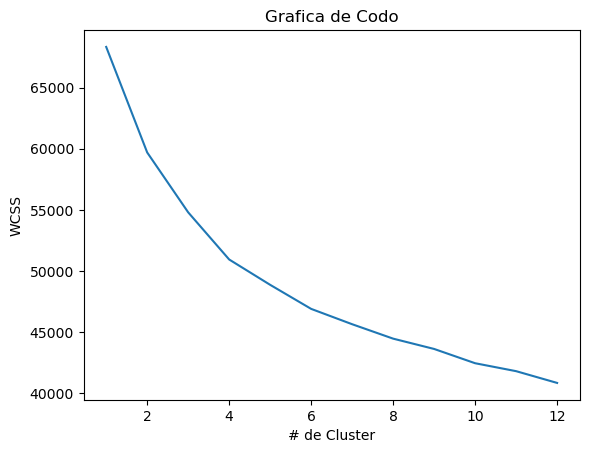

In [25]:
plt.plot(range(1,13),wcss)
plt.title("Grafica de Codo")
plt.xlabel("# de Cluster")
plt.ylabel("WCSS")
plt.show()

- De la grafica podemos apreciar que el # de Cluster optimos con los cuales trabajara sera 4

In [26]:
# se procede a definir y entrenar el Cluster de Kmeans con el # de clusters y unas 300 iteraciones como maximo
clustering = KMeans(n_clusters = 4, max_iter = 300)
clustering.fit(dsNorm)

KMeans(n_clusters=4)

In [35]:
centers = clustering.cluster_centers_
centers

array([[ 2.26711993e-01,  1.32326434e-01,  1.99767698e-02,
         1.64143768e-03,  4.29890358e-01,  6.26754578e-01,
         7.09455440e-01,  6.95342960e-01,  9.95245199e-01,
         1.88539386e-01,  5.25430622e-01,  5.37764122e-01,
         5.29419686e-01,  5.16242982e-01,  5.04624842e-01,
         4.97663565e-01,  7.96817702e-02,  5.17300401e-01,
         4.04966126e-01,  3.15148031e-01,  1.13431537e-01,
         4.33008059e-03,  3.37290488e-02,  1.46684070e-02,
         2.77705264e-02,  1.86462801e-04,  1.61601094e-03,
         1.77761203e-02,  4.42662689e-02,  6.68158369e-02,
        -1.27935856e-17, -2.92734587e-18,  1.49688193e-02,
         7.29207671e-02,  3.67547393e-01,  1.26359625e-01,
         4.83104398e-01,  6.32310896e-01,  3.66710175e-03,
         6.02896389e-03],
       [ 7.55874585e-01,  7.54165698e-01,  2.10052895e-02,
         3.55097123e-03,  4.14942038e-01,  6.20763450e-01,
         7.09303484e-01,  7.11539295e-01,  9.99651244e-01,
         7.35191430e-01,  5.31

In [27]:
dataset4 = pd.read_csv('part1.csv',encoding = "ANSI")

In [28]:
# Ahora las etiquetas del cluster se las une al dataset original a fin de conocer el # de cluster en el que fue asignada cada ciudad
dataset4['KMeans_Cluster'] = clustering.labels_
dataset4

,Unnamed: 0,ID,ANIO,LESIONADOS,FALLECIDOS,LATITUD_Y,LONGITUD_X,PROVINCIA,CANTON,PARROQUIA,...,TRICIMOTO,VEHICULO_DEPORTIVO_UTILITARIO,SUMA_DE_VEHICULOS,EDAD_1,SEXO_1,CONDICION_1,PARTICIPANTE_1,CASCO_1,CINTURON_1,KMeans_Cluster
0,0,1,2017,1,0,-0.083501,-78.417742,PICHINCHA,QUITO,CALDERON (CARAPUNGO),...,0,0,1,36,MUJER,LESIONADO,PEATON,NO,NO,3
1,3,4,2017,0,0,-0.116059,-78.464188,PICHINCHA,QUITO,QUITO,...,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO,2
2,4,5,2017,0,0,-0.239721,-78.512058,PICHINCHA,QUITO,QUITO,...,0,0,1,11,HOMBRE,ILESO,PASAJERO,NO,NO,0
3,5,6,2017,0,0,-0.116354,-78.465037,PICHINCHA,QUITO,QUITO,...,0,1,3,36,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO,0
4,11,12,2017,0,0,-0.242463,-78.482784,PICHINCHA,QUITO,QUITO,...,0,0,1,-1,NO IDENTIFICADO,NO IDENTIFICADO,CONDUCTOR AUSENTE,NO,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36178,156391,156392,2023,0,0,-0.146238,-78.475061,PICHINCHA,QUITO,QUITO,...,0,0,2,52,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO,1
36179,156393,156394,2023,1,0,-0.198275,-78.495738,PICHINCHA,QUITO,QUITO,...,0,0,1,9,MUJER,LESIONADO,PEATON,NO,NO,1
36180,156399,156400,2023,2,0,-0.250097,-78.521065,PICHINCHA,QUITO,QUITO,...,0,0,1,26,HOMBRE,LESIONADO,PEATON,NO,NO,1
36181,156403,156404,2023,0,0,-0.182953,-78.477835,PICHINCHA,QUITO,QUITO,...,0,0,2,41,HOMBRE,ILESO,CONDUCTOR PRESENTE,NO,NO,1


In [29]:
# Procedemos a realizar u analizis PCa a fin de que nos muetre de manera grafica los datos mas significativos dentro del Cluster
pca = PCA(n_components=3)
pca.fit(dsNorm)
pca_Transit = pca.transform(dsNorm)


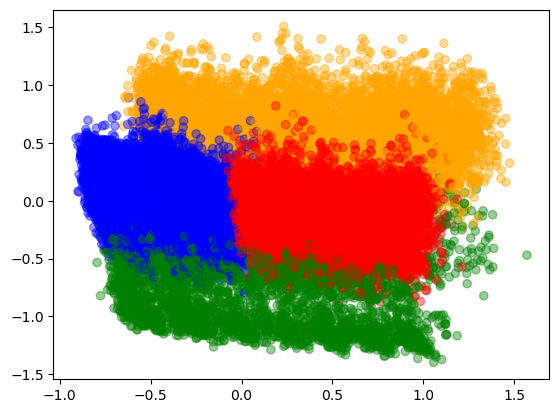

In [30]:
centroides, etiquetas = clustering.cluster_centers_,clustering.labels_
colores = ['blue', 'red', 'green', 'orange', 'gray', 'brown']
#Se asignan los colores a cada clústeres
colores_cluster = [colores[etiquetas[i]] for i in range(len(pca_Transit))]

plt.scatter(pca_Transit[:, 0], pca_Transit[:, 1], c = colores_cluster, 
            marker = 'o',alpha = 0.4)


In [31]:
# Exportamos el Dataset con el que vamos a trabajar a un formato CSV 
TFM = dataset4.to_csv('accidentes_Pichinca_Cluster_V1.csv')

In [32]:
dataset4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36183 entries, 0 to 36182
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     36183 non-null  int64  
 1   ID                             36183 non-null  int64  
 2   ANIO                           36183 non-null  int64  
 3   LESIONADOS                     36183 non-null  int64  
 4   FALLECIDOS                     36183 non-null  int64  
 5   LATITUD_Y                      36183 non-null  float64
 6   LONGITUD_X                     36183 non-null  float64
 7   PROVINCIA                      36183 non-null  object 
 8   CANTON                         36183 non-null  object 
 9   PARROQUIA                      36183 non-null  object 
 10  ZONA                           36183 non-null  object 
 11  FECHA                          36183 non-null  object 
 12  HORA                           36183 non-null 

In [33]:
vehiculos = dataset4.groupby('TIPO_DE_VEHICULO_1').size()
vehiculos

TIPO_DE_VEHICULO_1
AUTOMOVIL                        16251
BICICLETA                          331
BUS                               2207
CAMION                            2128
CAMIONETA                         3301
EMERGENCIAS                         10
ESPECIAL                            98
FURGONETA                          744
MOTOCICLETA                       6259
NO IDENTIFICADO                   3111
SCOOTER ELECTRICO                   22
TRICIMOTO                            3
VEHICULO DEPORTIVO UTILITARIO     1718
dtype: int64

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Realice en este espacio todo el análsis de resultados final incluyendo: ventajas y desventajas de cada modelo propuesto, Resultados comparados. Conclusiones objetivas y significantes con base a las diferentes métricas escogidas. Recomendaciones de mejora de las propuestas: 